In [1]:
import qiskit
print(f"Qiskit version: {qiskit.__version__}")

Qiskit version: 1.4.5


In [2]:
# # Check that the account has been saved properly
# from qiskit_ibm_runtime import QiskitRuntimeService

# service = QiskitRuntimeService(name="qgss-2025")
# service.saved_accounts()

d:\MyPrograms\miniconda\envs\qiskit\lib\site-packages\qiskit_ibm_runtime\api\auth.py:67: UserWarning: Unable to retrieve IBM Cloud access token. API Key will be used instead. Error: Cannot log in to the account because it is blocked., Status code: 400
  warnings.warn(
qiskit_runtime_service._discover_backends_from_instance:WARNING:2025-11-27 13:02:28,039: Invalid instance crn:v1:bluemix:public:quantum-computing:us-east:a/41b8ca65ee7f46799ee46a27b8d24ebd:ac605fda-c1f5-4a59-8c3e-8a74c6e7abcd::


{'qgss-2025': {'channel': 'ibm_quantum_platform',
  'url': 'https://cloud.ibm.com',
  'token': 'SdLPpLQVGu6qIZFCVHM_NlXgLclPl6ChHutUjeeZcXxq',
  'instance': 'crn:v1:bluemix:public:quantum-computing:us-east:a/41b8ca65ee7f46799ee46a27b8d24ebd:ac605fda-c1f5-4a59-8c3e-8a74c6e7abcd::',
  'verify': True,
  'private_endpoint': False}}

In [3]:
# Essential libraries
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import io
from PIL import Image
import random

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import Parameter
from qiskit.visualization import plot_histogram, plot_distribution
from qiskit_ibm_runtime import Options, Session, SamplerV2 as Sampler
from qiskit.result import marginal_distribution
from qiskit.quantum_info import Statevector, Pauli, Operator, SparsePauliOp

from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator

In [4]:
def client_qkd_chsh_circuit(assigned_a: int) -> QuantumCircuit:
    if assigned_a not in range(3):
        raise ValueError("assigned_a must be between 0 and 2.")
    
    qc = QuantumCircuit(2, 2, name=f'CHSH')

    # Create the Bell state |Φ+> = (|00> + |11>)/sqrt(2)
    qc.h(0)
    qc.cx(0, 1)

    qc.barrier()

    if assigned_a == 0: # Alice measures in 0 degrees angle (Z basis)
        pass
    elif assigned_a == 1: # Alice measures in 45 degrees angle
        qc.ry(-np.pi/4, 0)
    elif assigned_a == 2: # Alice measures in 90 degrees angle (X basis)
        qc.h(0)

    # Measure the qubits
    qc.measure(0, 0)  # Measure Alice's qubit

    return qc

In [5]:
def server_qkd_chsh_circuit(qc: QuantumCircuit, assigned_b: int) -> QuantumCircuit:
    if assigned_b not in range(3):
        raise ValueError("assigned_b must be between 0 and 2.")
    
    if assigned_b == 0: # Bob measures in 45 degrees angle
        qc.ry(-np.pi/4, 1)
    elif assigned_b == 1: # Bob measures in 90 degrees angle (X basis)
        qc.h(1)
    elif assigned_b == 2: # Bob measures in 135 degrees angle
        qc.ry(np.pi/4, 1)
    
    qc.measure(1, 1)  # Measure Bob's qubit

    return qc

Circuit 1:


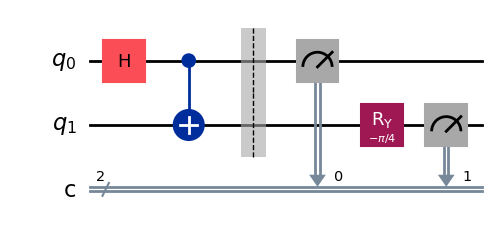



Circuit 2:


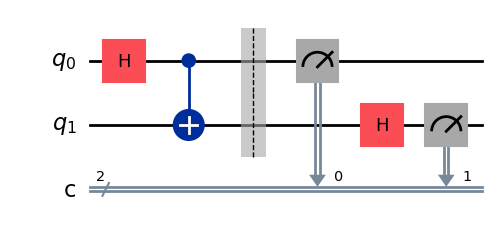



Circuit 3:


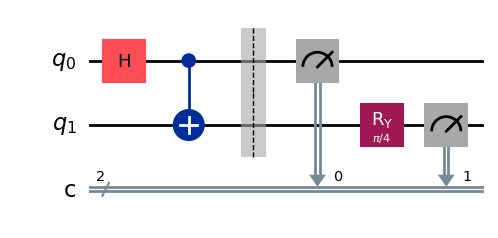



Circuit 4:


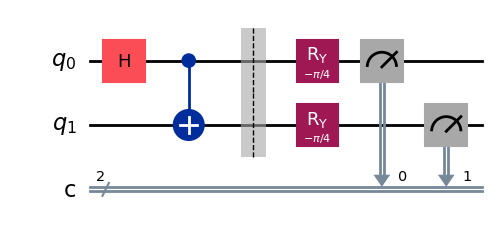



Circuit 5:


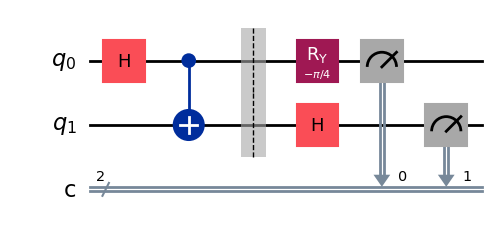



Circuit 6:


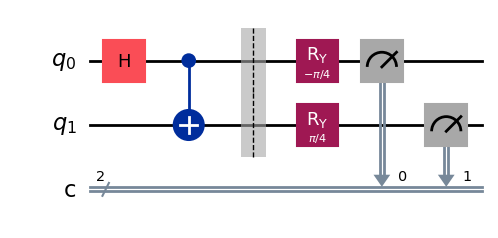



Circuit 7:


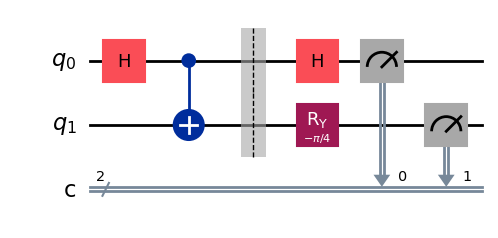



Circuit 8:


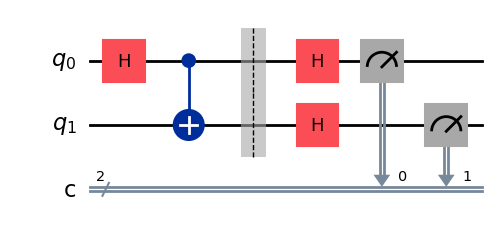



Circuit 9:


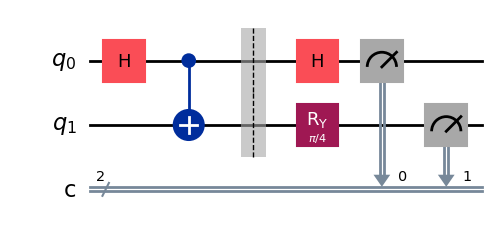

In [6]:
circuits = []
for x in range(3):
    for y in range(3):
        qc = client_qkd_chsh_circuit(x)
        qc = server_qkd_chsh_circuit(qc, y)
        circuits.append(qc)

# Display the circuits
for i, circuit in enumerate(circuits):
    print(f"Circuit {i+1}:")
    display(circuit.draw('mpl'))
    print("\n")

Circuit 4, 8: Keep as KeyGen (As the measurment angles are the same)

Circuit 1, 3, 5, 7: Keep as CHSH Test (As the measurement angles are differing by 25 degrees)

Circuit 2, 6, 9: Discard

In [7]:
total_trials = 200

results_dict = {}
circuit_num = 1
for circuit in circuits:
    for _ in range(total_trials):
        backend = AerSimulator()
        pm = generate_preset_pass_manager(backend=backend, optimization_level=1)

        isa_qc = pm.run([circuit])
        sampler = Sampler(mode=backend)
        job = sampler.run(isa_qc, shots=1)
        result = job.result()

        bitarray = result[0].data.c
        # bitstring = ''.join('1' if bit else '0' for bit in bitarray.to_bool_array()[0])
        bitstring = bitarray.get_bitstrings()[0]
        # print(f"Result {circuit_num}: {bitstring}")

        results_dict[circuit_num] = results_dict.get(circuit_num, [])
        results_dict[circuit_num].append(bitstring)
    circuit_num += 1

In [8]:
print("\nResults Dictionary:")
for circuit_num, results in results_dict.items():
    print(f"Circuit {circuit_num}: {results}")



Results Dictionary:
Circuit 1: ['01', '11', '11', '11', '00', '00', '00', '11', '00', '11', '11', '00', '01', '11', '00', '11', '11', '10', '01', '01', '11', '01', '11', '00', '11', '11', '11', '11', '11', '10', '10', '11', '00', '11', '01', '00', '11', '11', '00', '11', '11', '11', '00', '11', '00', '11', '00', '11', '00', '11', '00', '00', '00', '00', '11', '00', '10', '00', '10', '01', '00', '11', '11', '00', '00', '00', '11', '00', '00', '11', '10', '10', '11', '11', '11', '11', '00', '10', '00', '11', '00', '00', '11', '10', '11', '00', '10', '11', '11', '00', '11', '00', '00', '00', '11', '11', '11', '10', '11', '10', '00', '11', '11', '00', '11', '00', '11', '00', '00', '00', '10', '11', '00', '11', '11', '11', '11', '11', '00', '11', '11', '00', '01', '11', '00', '01', '11', '01', '00', '00', '00', '00', '11', '00', '00', '01', '00', '11', '11', '01', '11', '00', '01', '11', '11', '11', '01', '00', '11', '00', '01', '10', '00', '11', '11', '00', '11', '00', '11', '00', '00', '

In [9]:
win_total = 0
for circuit_num, results in results_dict.items():
    if circuit_num == 4 or circuit_num == 8: # KeyGen circuits
        same_bit  = True
        for result in results:
            if result[0] != result[1]:
                same_bit = False
                break
        print(f"Circuit {circuit_num} (KeyGen) results are the same: {same_bit}")
    elif circuit_num in [1, 3, 5, 7]: # CHSH test circuits
        total_trials = len(results)
        win = 0
        for result in results:
            if result[0] == result[1]:
                win += 1
        print(f"Circuit {circuit_num} (CHSH) win rate: {win / total_trials * 100:.2f}%")
        win_total += win
    elif circuit_num in [2, 6, 9]: # Discarded circuits
        print(f"Circuit {circuit_num} (Discarded) results are not used.")
print(f"\nTotal win rate: {win_total / 4 / total_trials * 100:.2f}%")

Circuit 1 (CHSH) win rate: 82.00%
Circuit 2 (Discarded) results are not used.
Circuit 3 (CHSH) win rate: 84.50%
Circuit 4 (KeyGen) results are the same: True
Circuit 5 (CHSH) win rate: 89.00%
Circuit 6 (Discarded) results are not used.
Circuit 7 (CHSH) win rate: 84.50%
Circuit 8 (KeyGen) results are the same: True
Circuit 9 (Discarded) results are not used.

Total win rate: 85.00%
